## Etapa 0 - Estabelecer o Dataset

- Entender como está estrutura o dataset, quais são as colunas, o que cada coluna representa
- Chegar a um requisito inicial de 200 mil palavras para a análise de palavras

In [1]:
import pandas as pd

url = 'https://raw.githubusercontent.com/damarals/biblias/main/inst/json/NVT.json'

dfb = pd.read_json(url)

dfb.head()
dfb_joao = dfb[dfb['name'] == 'João']
# Mostrar o DataFrame atualizado
dfb_joao.head()

# Para acessar capitulos
# joao_chapters = dfb_joao['chapters'].iloc[0]

,abbrev,chapters,name
42,Jo,"[[No princípio, aquele que é a Palavra já exis...",João


### Análise da Estrutura do Dataset - Livro de João

Verificar como os capítulos e versículos estão organizados no dataset.

In [3]:
# Extrair dados do livro de João
joao_data = dfb_joao.iloc[0]
joao_chapters = joao_data['chapters']

# 1. Informações gerais
print(f"\n1. INFORMAÇÕES GERAIS:")
print(f"   - Nome do livro: {joao_data['name']}")
print(f"   - Abreviação: {joao_data.get('abbrev', 'N/A')}")
print(f"   - Tipo de 'chapters': {type(joao_chapters)}")
print(f"   - Total de capítulos: {len(joao_chapters)}")

# 2. Criar DataFrame estruturado por capítulo
chapter_data = []
total_verses = 0

for chapter_num, chapter_verses in enumerate(joao_chapters, start=1):
    num_verses = len(chapter_verses)
    total_verses += num_verses

    # Contar palavras no capítulo
    chapter_words = sum(len(verse.split()) for verse in chapter_verses)

    # Pegar exemplo do primeiro versículo
    first_verse_preview = chapter_verses[0][:80] + "..." if len(chapter_verses[0]) > 80 else chapter_verses[0]

    chapter_data.append({
        'Capítulo': chapter_num,
        'Num_Versículos': num_verses,
        'Total_Palavras': chapter_words,
        'Primeiro_Versículo': first_verse_preview
    })

# Criar DataFrame
df_joao_structure = pd.DataFrame(chapter_data)

print(f"\n2. RESUMO ESTATÍSTICO:")
print(f"   - Total de versículos no livro: {total_verses}")
print(f"   - Total de palavras no livro: {df_joao_structure['Total_Palavras'].sum()}")
print(f"   - Média de versículos por capítulo: {df_joao_structure['Num_Versículos'].mean():.1f}")
print(f"   - Média de palavras por capítulo: {df_joao_structure['Total_Palavras'].mean():.1f}")

print(f"\n3. ESTRUTURA POR CAPÍTULO:")
display(df_joao_structure)

# 3. Exemplo detalhado de um capítulo específico (Capítulo 1)
print(f"\n4. EXEMPLO DETALHADO - CAPÍTULO 1:")
print(f"   - Número de versículos: {len(joao_chapters[0])}")
print(f"\n   Primeiros 5 versículos:")

for verse_num, verse_text in enumerate(joao_chapters[0][:5], start=1):
    print(f"   [{verse_num}] {verse_text}")

# 4. Verificar se há estrutura aninhada adicional
print(f"\n5. VERIFICAÇÃO DE ANINHAMENTO:")
sample_verse = joao_chapters[0][0]
print(f"   - Tipo do primeiro versículo: {type(sample_verse)}")
print(f"   - É uma string? {'✓ SIM' if isinstance(sample_verse, str) else '✗ NÃO (estrutura aninhada detectada)'}")

if isinstance(sample_verse, str):
    print(f"   - Estrutura confirmada: chapters[capítulo_idx][versículo_idx] = string")
else:
    print(f"   - ATENÇÃO: Estrutura mais complexa detectada!")
    print(f"   - Conteúdo do primeiro item: {sample_verse}")


1. INFORMAÇÕES GERAIS:
   - Nome do livro: João
   - Abreviação: Jo
   - Tipo de 'chapters': <class 'list'>
   - Total de capítulos: 21

2. RESUMO ESTATÍSTICO:
   - Total de versículos no livro: 879
   - Total de palavras no livro: 16840
   - Média de versículos por capítulo: 41.9
   - Média de palavras por capítulo: 801.9

3. ESTRUTURA POR CAPÍTULO:


,Capítulo,Num_Versículos,Total_Palavras,Primeiro_Versículo
0,1,51,918,"No princípio, aquele que é a Palavra já existi..."
1,2,25,461,"Três dias depois, houve uma festa de casamento..."
2,3,36,713,"Havia um fariseu chamado Nicodemos, líder reli..."
3,4,54,1027,Jesus sabia que os fariseus tinham ouvido dize...
4,5,47,928,"Depois disso, Jesus voltou a Jerusalém para um..."
5,6,71,1275,"Depois disso, Jesus atravessou o mar da Galile..."
6,7,53,955,"Depois disso, Jesus viajou pela Galileia. Quer..."
7,8,59,1172,"Jesus voltou ao monte das Oliveiras,"
8,9,41,749,"Enquanto caminhava, Jesus viu um homem cego de..."
9,10,42,735,“Eu lhes digo a verdade: quem entra no curral ...



4. EXEMPLO DETALHADO - CAPÍTULO 1:
   - Número de versículos: 51

   Primeiros 5 versículos:
   [1] No princípio, aquele que é a Palavra já existia. A Palavra estava com Deus, e a Palavra era Deus.
   [2] Ele existia no princípio com Deus.
   [3] Por meio dele Deus criou todas as coisas, e sem ele nada foi criado.
   [4] Aquele que é a Palavra possuía a vida, e sua vida trouxe luz a todos.
   [5] A luz brilha na escuridão, e a escuridão nunca conseguiu apagá-la.

5. VERIFICAÇÃO DE ANINHAMENTO:
   - Tipo do primeiro versículo: <class 'str'>
   - É uma string? ✓ SIM
   - Estrutura confirmada: chapters[capítulo_idx][versículo_idx] = string


In [4]:
import pandas as pd

dfb_full = dfb

# Define lists of books for the New Testament and Wisdom books (Old Testament)
new_testament_books = [
    'Mateus', 'Marcos', 'Lucas', 'João', 'Atos', 'Romanos', '1 Coríntios', '2 Coríntios',
    'Gálatas', 'Efésios', 'Filipenses', 'Colossenses', '1 Tessalonicenses', '2 Tessalonicenses',
    '1 Timóteo', '2 Timóteo', 'Tito', 'Filemom', 'Hebreus', 'Tiago', '1 Pedro', '2 Pedro',
    '1 João', '2 João', '3 João', 'Judas', 'Apocalipse'
]

wisdom_books_ot = [
    'Jó', 'Salmos', 'Provérbios', 'Eclesiastes', 'Cânticos'
]

# Combine the lists of desired books
selected_books = new_testament_books + wisdom_books_ot

# Filter the DataFrame for these selected books
dfb_selected = dfb_full[dfb_full['name'].isin(selected_books)].copy()

# Initialize total word count for all selected books
total_words_all_selected_books = 0

print(f"Starting word count for {len(selected_books)} selected books:\n")

# Iterate through each selected book to count words
for index, row in dfb_selected.iterrows():
    book_name = row['name']
    book_chapters_data = row['chapters'] # This could be a complex nested structure
    current_book_word_count = 0

    # Flatten book_chapters_data into a single list of all verse strings
    all_verses_for_book = []

    def flatten_list_of_lists(nested_list):
        for item in nested_list:
            if isinstance(item, list):
                yield from flatten_list_of_lists(item)
            else:
                yield item

    # Apply flattening. This handles arbitrary levels of nesting until strings are found.
    for verse_candidate in flatten_list_of_lists(book_chapters_data):
        if isinstance(verse_candidate, str):
            all_verses_for_book.append(verse_candidate)
        else:
            # This case indicates an unexpected non-string item after deep flattening
            print(f"Warning: Found non-string item in {book_name} after flattening: {verse_candidate} (type: {type(verse_candidate)}) - skipping")

    # Now, all_verses_for_book should be a flat list of strings
    for verse_text in all_verses_for_book:
        words = verse_text.split() # verse_text is guaranteed to be a string here
        current_book_word_count += len(words)

    print(f"  Book: {book_name} - Total words: {current_book_word_count}")
    total_words_all_selected_books += current_book_word_count

print(f"\n------------------------------------------------")
print(f"Total words across all selected books: {total_words_all_selected_books}")


Starting word count for 32 selected books:

  Book: Jó - Total words: 15419
  Book: Salmos - Total words: 36889
  Book: Provérbios - Total words: 13210
  Book: Eclesiastes - Total words: 4724
  Book: Cânticos - Total words: 2449
  Book: Mateus - Total words: 20990
  Book: Marcos - Total words: 13305
  Book: Lucas - Total words: 22346
  Book: João - Total words: 16840
  Book: Atos - Total words: 21569
  Book: Romanos - Total words: 9899
  Book: 1 Coríntios - Total words: 9364
  Book: 2 Coríntios - Total words: 6100
  Book: Gálatas - Total words: 3215
  Book: Efésios - Total words: 2992
  Book: Filipenses - Total words: 2197
  Book: Colossenses - Total words: 2045
  Book: 1 Tessalonicenses - Total words: 1801
  Book: 2 Tessalonicenses - Total words: 1018
  Book: 1 Timóteo - Total words: 2419
  Book: 2 Timóteo - Total words: 1748
  Book: Tito - Total words: 1042
  Book: Filemom - Total words: 430
  Book: Hebreus - Total words: 6792
  Book: Tiago - Total words: 2172
  Book: 1 Pedro - Total

## Etapa 1 - **Pré-processamento Textual**

Etapa para preparar o texto da Bíblia em português.

In [7]:
# 1. Instalação de dependências e download de modelos
!pip install -q spacy nltk pandas gensim scikit-learn wordcloud
!python -m spacy download pt_core_news_md

import spacy
import nltk
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer
import pandas as pd
import re
from collections import Counter
from typing import List, Dict, Any
import json
from pathlib import Path

# Downloads necessários para o NLTK
nltk.download('stopwords')
nltk.download('rslp')

print("\n[INFO] Ambiente configurado com sucesso.")
# O modelo 'pt_core_news_sm' é essencial para o spaCy processar a língua portuguesa,
# permitindo análise morfológica e lemmatização precisa, diferente de modelos em inglês
# que utilizam regras gramaticais e vocabulários distintos.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 19.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.

[INFO] Ambiente configurado com sucesso.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Package rslp is already up-to-date!


### Normalização de Clíticos

**Motivação**

O português possui alta variação morfológica e ortográfica em formas verbais e pronominais, por exemplo:

- flexão verbal
- composição com pronomes
- hifenização
- variações antigas da linguagem

Isso faz o vocabulário "explodir" artificialmente, prejudicando a qualidade de lematização e a consistência dos tópicos.

**Exemplos de variação encontradas no vocabulario**

- "ajoelhar se"
- "ajoelhar-se"
- "ajoelhavam-se"
- "ajoelhou se"
- "ajoelhou-se"
- "ajoelhour se"
- "ajuda nós"
- "ajuda-a"
- "ajuda-me"
- "ajuda-nos"
- "ajuda-o"
- "ajuda-os"

**Impacto esperado**

A normalização ocorre antes do spaCy, reduzindo variações superficiais e aumentando a chance de o lematizador convergir para a forma canônica. Isso tende a melhorar a densidade semântica e a estabilidade dos tópicos.

In [6]:
def normalize_clitics(text: str) -> str:
    """Remove pronomes encliticos comuns do portugues."""
    pattern = r'-(me|te|se|na|nas|no|nos|vos|lo|los|la|las|lhe|lhes|o|a|os|as)\b'
    return re.sub(pattern, '', text)


class BiblePreprocessor:
    """Classe para pre-processamento de texto biblico focado em Topic Modeling."""

    def __init__(self, custom_stopwords: List[str] = None):
        # Carregando spaCy pt_core_news_md para analise contextual
        self.nlp = spacy.load("pt_core_news_md")

        # Configuracao de Stopwords (NLTK + Custom)
        base_stopwords = set(stopwords.words('portuguese'))
        if custom_stopwords:
            base_stopwords.update(custom_stopwords)
        self.stop_words = base_stopwords

        self.stemmer = RSLPStemmer()  # Para comparacao academica

    def clean_text(self, text: str) -> str:
        """Limpeza inicial: remocao de ruidos basicos."""
        text = text.lower()
        text = re.sub(r'\d+', '', text)  # Remove numeros
        text = re.sub(r'\s+', ' ', text).strip()  # Remove espacos extras
        return text

    def process_pipeline(self, text: str) -> List[str]:
        """
        Executa normalizacao de cliticos, Tokenizacao, Lematizacao e POS Filtering.
        Mantem apenas NOUN, VERB, ADJ para densidade semantica no Topic Modeling.
        """
        text = normalize_clitics(text)
        text = self.clean_text(text)
        doc = self.nlp(text)

        tokens_limpos = []
        for token in doc:
            # POS Filtering: Substantivos, Verbos e Adjetivos carregam o topico
            if token.pos_ in ['NOUN', 'VERB', 'ADJ']:
                # Lematizacao para reduzir dimensionalidade sem perder semantica
                lemma = token.lemma_
                if lemma not in self.stop_words and len(lemma) > 2:
                    tokens_limpos.append(lemma)

        return tokens_limpos

In [8]:
# 2. Execução e Análise Quantitativa
custom_stops = ['capítulo', 'versículo', 'bíblia', 'livro']
preprocessor = BiblePreprocessor(custom_stopwords=custom_stops)

def get_book_text(chapters_data: Any) -> str:
    """Achata a estrutura de capítulos/versículos em uma única string."""
    def flatten(nested):
        for item in nested:
            if isinstance(item, list):
                yield from flatten(item)
            else:
                yield item
    return " ".join([str(v) for v in flatten(chapters_data)])

print(f"Processando {len(dfb_selected)} livros selecionados...")

corpus_final = []
for _, row in dfb_selected.iterrows():
    # Agrega todo o texto do livro de forma robusta
    full_text = get_book_text(row['chapters'])
    tokens = preprocessor.process_pipeline(full_text)
    corpus_final.append(tokens)

print(f"\n[INFO] Corpus processado. Total de documentos: {len(corpus_final)}")
print(f"Exemplo de tokens (primeiros 10 de {dfb_selected['name'].iloc[0]}):", corpus_final[0][:10])

Processando 32 livros selecionados...

[INFO] Corpus processado. Total de documentos: 32
Exemplo de tokens (primeiros 10 de Jó): ['homem', 'chamar', 'viver', 'terra', 'íntegro', 'correto', 'temer', 'deus', 'manter', 'afastar']


In [9]:
# 3. Análise Quantitativa e Métricas de Impacto

def calculate_metrics(tokens_list: List[str]) -> Dict[str, Any]:
    """Calcula métricas básicas de NLP para análise de densidade lexical."""
    total_tokens = len(tokens_list)
    vocab_size = len(set(tokens_list))
    ttr = vocab_size / total_tokens if total_tokens > 0 else 0
    return {
        "total_tokens": total_tokens,
        "vocab_size": vocab_size,
        "ttr": round(ttr, 4)
    }

# Analisando o impacto (Exemplo com o primeiro livro)
first_book_name = dfb_selected['name'].iloc[0]
raw_text_example = get_book_text(dfb_selected['chapters'].iloc[0])
raw_tokens = raw_text_example.split()

metrics_raw = calculate_metrics(raw_tokens)
metrics_processed = calculate_metrics(corpus_final[0])

# Criando tabela comparativa de impacto
df_impacto = pd.DataFrame({
    "Métrica": ["Total de Tokens", "Tamanho do Vocabulário", "Type-Token Ratio (TTR)"],
    "Original": [metrics_raw['total_tokens'], metrics_raw['vocab_size'], metrics_raw['ttr']],
    "Pós-Processamento": [metrics_processed['total_tokens'], metrics_processed['vocab_size'], metrics_processed['ttr']]
})

print(f"\n[ANÁLISE] Impacto do Pré-processamento no livro: {first_book_name}")
display(df_impacto)

# Justificativa Técnica:
# A redução no tamanho do vocabulário e o ajuste do TTR são fundamentais para LDA/NMF.
# Menos 'ruído' (tokens irrelevantes) permite que o modelo foque em padrões probabilísticos
# de palavras que realmente definem o conteúdo semântico dos tópicos."

# 4. Geração do Corpus Final e Persistência

# Preparando listas para Topic Modeling (Gensim e Sklearn)
# corpus_final já é uma lista de listas de tokens

# Exportação para JSON (Vocabulário)
all_tokens_flat = [t for doc in corpus_final for t in doc]
vocabulario = sorted(list(set(all_tokens_flat)))

output_path = Path("preprocessed_bible")
output_path.mkdir(exist_ok=True)

with open(output_path / "vocabulario.json", "w", encoding="utf-8") as f:
    json.dump(vocabulario, f, ensure_ascii=False, indent=4)

# Salvando corpus preprocessado
with open(output_path / "corpus_final.txt", "w", encoding="utf-8") as f:
    for doc_tokens in corpus_final:
        f.write(" ".join(doc_tokens) + "\n")

print(f"\nPipeline finalizado.")
print(f"- Arquivos salvos em: {output_path}/")
print(f"- Vocabulário final: {len(vocabulario)} termos únicos.")



[ANÁLISE] Impacto do Pré-processamento no livro: Jó


,Métrica,Original,Pós-Processamento
0,Total de Tokens,15419.0000,6666.0000
1,Tamanho do Vocabulário,4836.0000,2092.0000
2,Type-Token Ratio (TTR),0.3136,0.3138



Pipeline finalizado.
- Arquivos salvos em: preprocessed_bible/
- Vocabulário final: 7800 termos únicos.


### Resultado Visual da Etapa 1: WordCloud

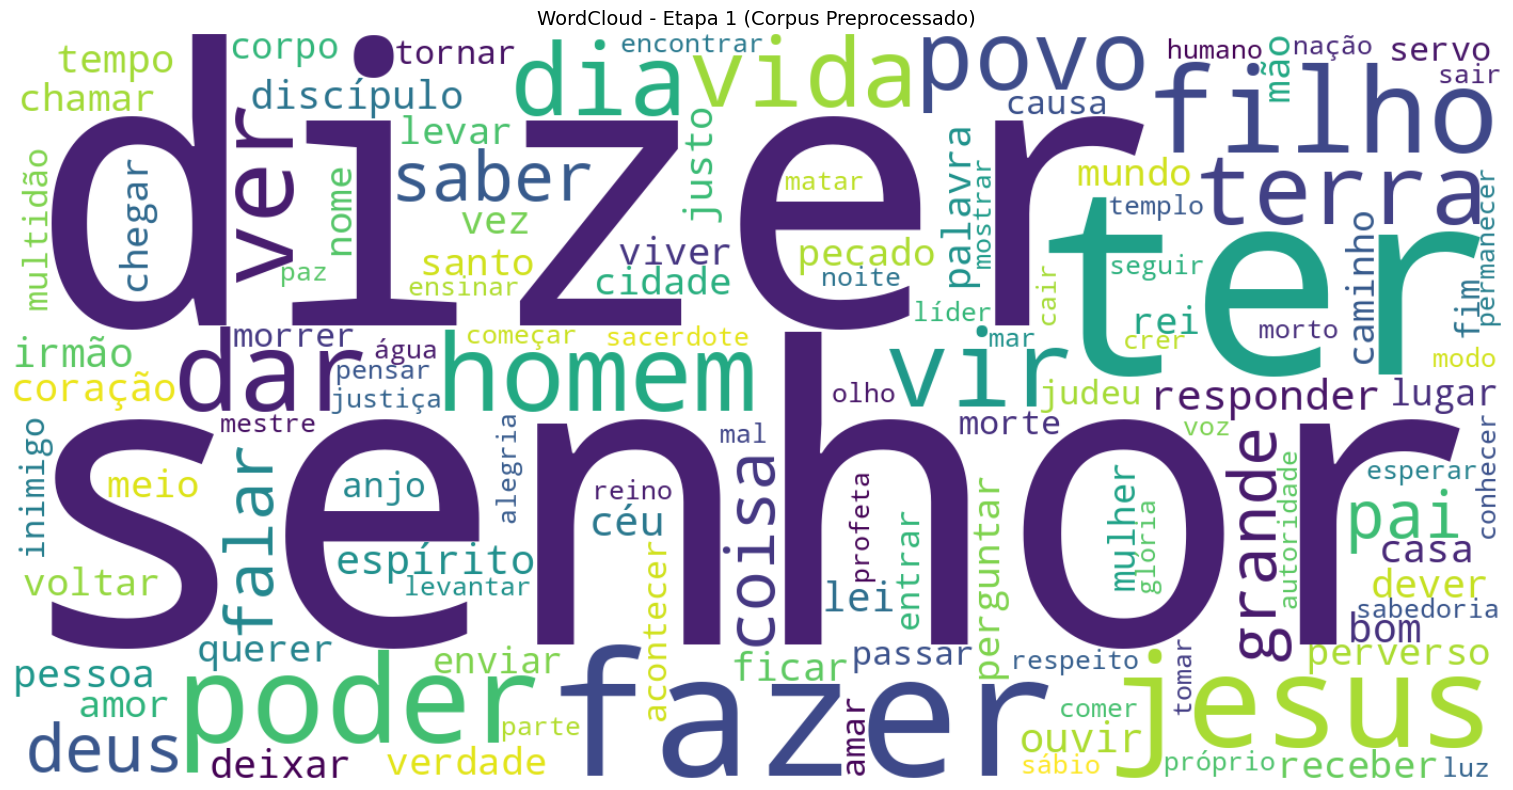

In [11]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

# Garante que o corpus possui dados antes de gerar a visualização
if not all_tokens_flat:
    raise ValueError("all_tokens_flat está vazio. Execute a etapa de pré-processamento antes da WordCloud.")

# Frequências a partir do corpus já preprocessado
frequencias = Counter(all_tokens_flat)

# Geração da WordCloud
wc = WordCloud(
    width=1400,
    height=700,
    background_color="white",
    max_words=120,
    collocations=False,
    random_state=42
).generate_from_frequencies(frequencias)

# Exibição
plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title(
    f"WordCloud - Etapa 1 (Corpus Preprocessado)",
    fontsize=14
)
plt.tight_layout()
plt.show()

# Persistência em arquivo
output_dir = Path("preprocessed_bible")
output_dir.mkdir(exist_ok=True)
output_file = output_dir / "wordcloud_etapa1.png"
wc.to_file(str(output_file))

## Distribuição de termos frequentes


ANÁLISE DE DISTRIBUIÇÃO DE FREQUÊNCIAS POR LIVRO

[TABELA] Estatísticas de Frequência por Livro:



,total_tokens,unique_terms,mean_freq,median_freq,std_freq,min_freq,max_freq,ttr
Jó,6666.0,2092.0,3.19,1.0,6.06,1.0,103.0,0.31
Salmos,15787.0,2998.0,5.27,2.0,18.65,1.0,810.0,0.19
Provérbios,6290.0,1781.0,3.53,1.0,7.38,1.0,106.0,0.28
Eclesiastes,2007.0,811.0,2.47,1.0,4.51,1.0,63.0,0.40
Cânticos,1060.0,538.0,1.97,1.0,2.34,1.0,31.0,0.51
Mateus,8853.0,1953.0,4.53,2.0,11.12,1.0,267.0,0.22
Marcos,5584.0,1462.0,3.82,1.0,8.75,1.0,171.0,0.26
Lucas,9328.0,2084.0,4.48,2.0,12.27,1.0,301.0,0.22
João,6464.0,1294.0,5.00,2.0,14.04,1.0,314.0,0.20
Atos,8952.0,1980.0,4.52,2.0,9.88,1.0,173.0,0.22



[VISUALIZAÇÃO] Distribuição de Frequências por Livro:


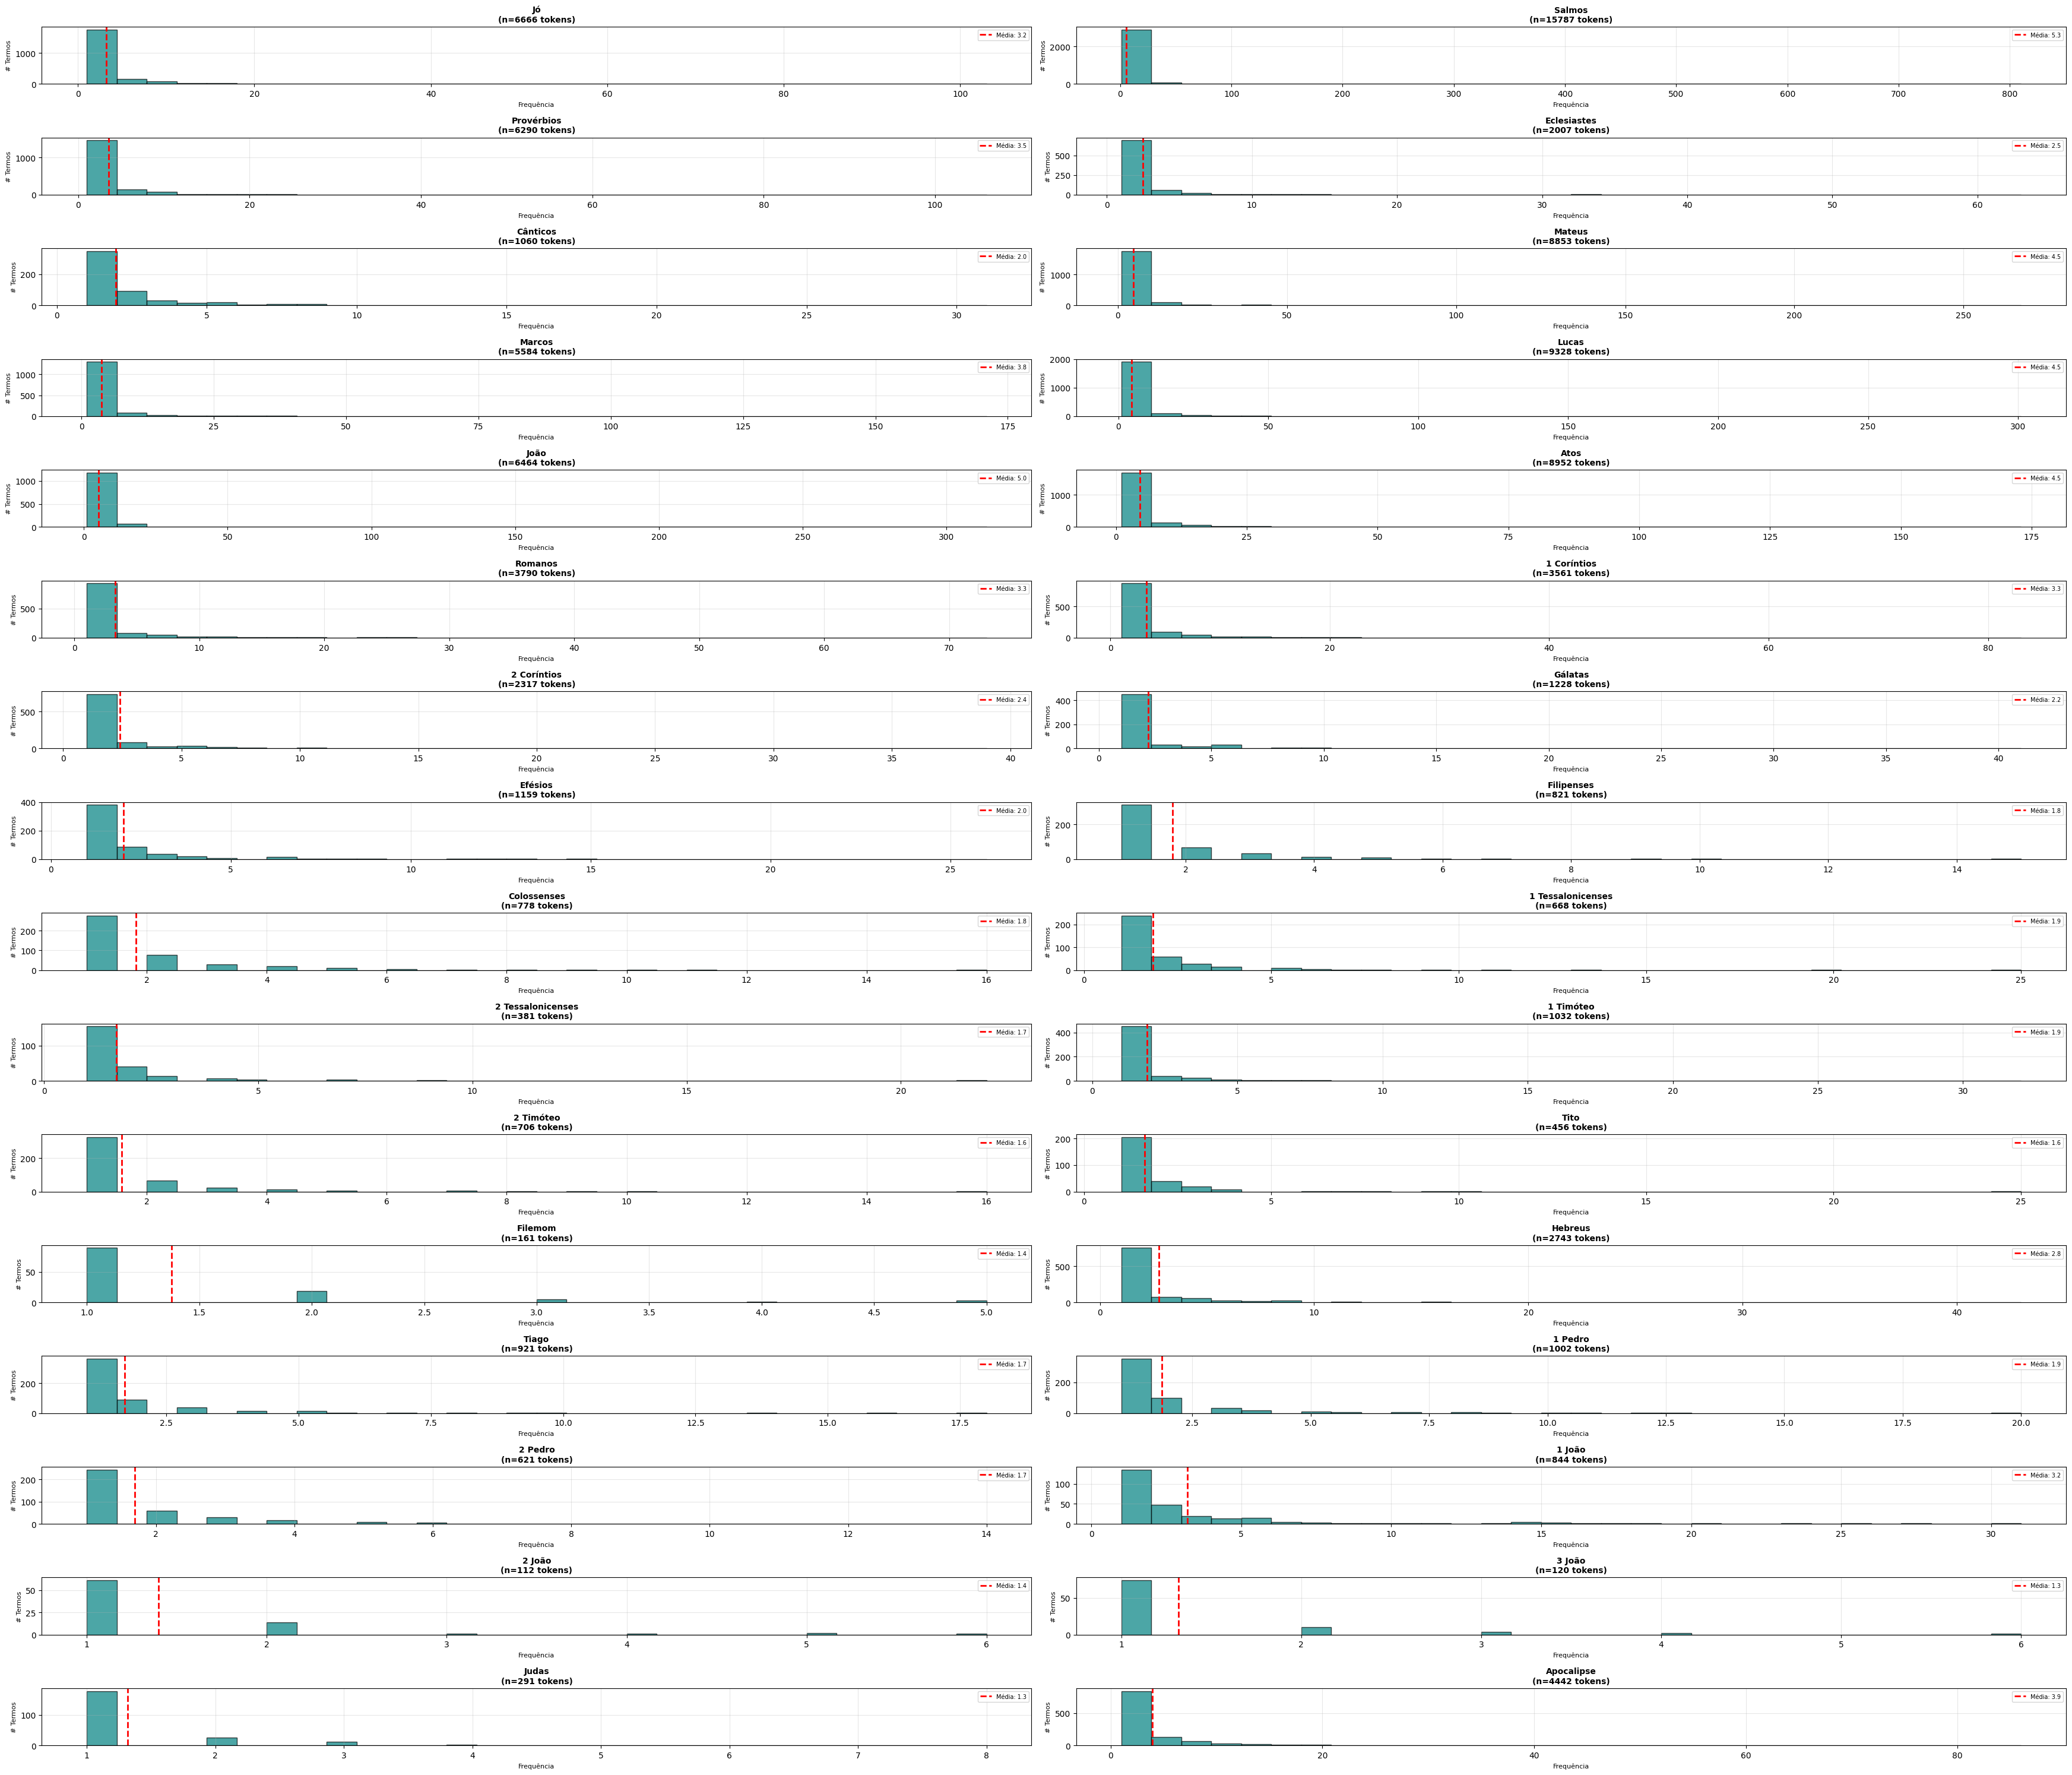


[COMPARAÇÃO] Top 10 Livros por Número de Tokens Únicos:


,total_tokens,unique_terms,ttr
Salmos,15787.0,2998.0,0.19
Jó,6666.0,2092.0,0.31
Lucas,9328.0,2084.0,0.22
Atos,8952.0,1980.0,0.22
Mateus,8853.0,1953.0,0.22
Provérbios,6290.0,1781.0,0.28
Marcos,5584.0,1462.0,0.26
João,6464.0,1294.0,0.20
Romanos,3790.0,1158.0,0.31
Apocalipse,4442.0,1136.0,0.26



[COMPARAÇÃO] Top 10 Livros por Type-Token Ratio (Diversidade Lexical):


,total_tokens,unique_terms,ttr
3 João,120.0,91.0,0.76
Judas,291.0,221.0,0.76
Filemom,161.0,117.0,0.73
2 João,112.0,80.0,0.71
2 Timóteo,706.0,445.0,0.63
Tito,456.0,281.0,0.62
2 Tessalonicenses,381.0,225.0,0.59
2 Pedro,621.0,366.0,0.59
Tiago,921.0,537.0,0.58
Filipenses,821.0,456.0,0.56


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

# Análise de frequência por livro
print("=" * 80)
print("ANÁLISE DE DISTRIBUIÇÃO DE FREQUÊNCIAS POR LIVRO")
print("=" * 80)

# Dicionário para armazenar estatísticas por livro
book_statistics = {}

for book_idx, (book_name, tokens) in enumerate(zip(dfb_selected['name'], corpus_final)):
    freq_counter = Counter(tokens)
    freq_values = list(freq_counter.values())

    # Calcular estatísticas
    stats = {
        'total_tokens': len(tokens),
        'unique_terms': len(freq_counter),
        'mean_freq': np.mean(freq_values),
        'median_freq': np.median(freq_values),
        'std_freq': np.std(freq_values),
        'min_freq': np.min(freq_values),
        'max_freq': np.max(freq_values),
        'ttr': len(freq_counter) / len(tokens) if len(tokens) > 0 else 0
    }

    book_statistics[book_name] = stats

# Tabela comparativa de todos os livros
df_books_stats = pd.DataFrame(book_statistics).T
df_books_stats = df_books_stats.round(2)

print("\n[TABELA] Estatísticas de Frequência por Livro:\n")
display(df_books_stats)

# Visualização: Histogramas por livro (Grid com subplots)
print("\n[VISUALIZAÇÃO] Distribuição de Frequências por Livro:")

# Criar grid de subplots (3 colunas para 32 livros)
n_books = len(dfb_selected)
n_cols = 2 # Alterado para 2 colunas
n_rows = (n_books + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(35, 30)) # Increased figsize
axes = axes.flatten()  # Achatar para iteração fácil

for idx, (book_name, tokens) in enumerate(zip(dfb_selected['name'], corpus_final)):
    freq_counter = Counter(tokens)
    freq_values = list(freq_counter.values())

    ax = axes[idx]
    ax.hist(freq_values, bins=30, color='teal', alpha=0.7, edgecolor='black')
    ax.set_title(f'{book_name}\n(n={len(tokens)} tokens)', fontsize=10, fontweight='bold')
    ax.set_xlabel('Frequência', fontsize=8)
    ax.set_ylabel('# Termos', fontsize=8)
    ax.grid(True, alpha=0.3)

    # Adicionar estatísticas no gráfico
    mean_f = book_statistics[book_name]['mean_freq']
    ax.axvline(mean_f, color='red', linestyle='--', linewidth=2, label=f'Média: {mean_f:.1f}')
    ax.legend(fontsize=7)

# Remover subplots vazios
for idx in range(n_books, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig(output_dir / "frequency_distribution_by_book.png", dpi=100, bbox_inches='tight')
plt.show()

# Análise de Variação: Comparação entre Livros
print("\n[COMPARAÇÃO] Top 10 Livros por Número de Tokens Únicos:")
top_books_unique = df_books_stats.nlargest(10, 'unique_terms')[['total_tokens', 'unique_terms', 'ttr']]
display(top_books_unique)

print("\n[COMPARAÇÃO] Top 10 Livros por Type-Token Ratio (Diversidade Lexical):")
top_books_ttr = df_books_stats.nlargest(10, 'ttr')[['total_tokens', 'unique_terms', 'ttr']]
display(top_books_ttr)

## Etapa 2 - **Representação vetorial e busca textual**

## Etapa 3 - **Modelagem, classificação ou análise de sentimento**

## Etapa 4 - **NER, extração de informação e grafo de conhecimento**

## Etapa 5 - **Visualização, comunicação e reprodutibilidade**